# AL2002 — Artificial Intelligence Lab
## Lab Exercise 08 · Data Preprocessing & Exploratory Data Analysis

---

| Field | Details |
|---|---|
| **Student Name** | *Zohaib Hussain* |
| **Roll Number** | *23L-3087* |
| **Semester** | Spring 2026 |
| **Department** | Computer Science — FAST-NU, Lahore |

---

> ⚠️ **Before submitting:**
> - Fill in your **Student Name** and **Roll Number** in the table above.
> - Make sure **all cells are executed** and outputs are visible.
> - Rename this file to your **roll number** (e.g. `21K-3456.ipynb`) before downloading.

---
## Imports & Dataset

Run this cell first. **Do not modify the dataset.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from scipy.stats import skew

pd.set_option('display.max_columns', None)

data = {
    'Student_ID':         ['F21SE001','F21SE002','F21SE003','F21SE004','F21SE005',
                           'F21SE006','F21SE007','F21SE008','F21SE009','F21SE001'],
    'Gender':             ['Male','Female','Male','Female','Male',
                           'Female','Male','Female','Male','Male'],
    'City':               ['Lahore','Karachi','Islamabad','Lahore', None,
                           'Karachi','Lahore', None,'Islamabad','Lahore'],
    'CGPA':               [3.85, 2.90, None, 3.50, 3.10,
                           2.75, None, 3.60, 3.20, 3.85],
    'Graduation_Year':    ['2024','2024','2023','2023','2024',
                           '2023','2024','2023','2024','2024'],
    'Specialization':     ['AI','SE','CYS','AI','SE',
                           'CYS','AI','SE', None,'AI'],
    'Job_Status':         ['Employed','Unemployed','Employed','Employed','Unemployed',
                           'Employed','Employed','Unemployed','Employed','Employed'],
    'Job_Sector':         ['Tech','N/A','Finance','Tech','N/A',
                           'Government','Tech','N/A','Finance','Tech'],
    'Monthly_Salary_PKR': ['150,000','0','95,000','?','0',
                           '80,000','200,000','0','120,000','150,000'],
    'Experience_Months':  [14, 0, 8, 18, 0, 10, 22, 0, 15, 14],
    'Skill_Level':        ['Advanced','Beginner','Intermediate','Advanced','Beginner',
                           'Intermediate','Advanced','Beginner','Intermediate','Advanced'],
    'Higher_Studies':     ['No','Yes','No','No','Yes',
                           'No','No','Yes','No','No'],
    'Joined_Date':        ['15-Aug-2024','2024/09/01','September 10, 2024','2024-10-05',
                           '01-Nov-2024','2024-08-20','2024/07/15','30-Sep-2024',
                           '2024-08-01','15-Aug-2024']
}

df = pd.DataFrame(data)
df

,Student_ID,Gender,City,CGPA,Graduation_Year,Specialization,Job_Status,Job_Sector,Monthly_Salary_PKR,Experience_Months,Skill_Level,Higher_Studies,Joined_Date
0,F21SE001,Male,Lahore,3.85,2024,AI,Employed,Tech,"150,000",14,Advanced,No,15-Aug-2024
1,F21SE002,Female,Karachi,2.90,2024,SE,Unemployed,N/A,0,0,Beginner,Yes,2024/09/01
2,F21SE003,Male,Islamabad,NaN,2023,CYS,Employed,Finance,"95,000",8,Intermediate,No,"September 10, 2024"
3,F21SE004,Female,Lahore,3.50,2023,AI,Employed,Tech,?,18,Advanced,No,2024-10-05
4,F21SE005,Male,NaN,3.10,2024,SE,Unemployed,N/A,0,0,Beginner,Yes,01-Nov-2024
5,F21SE006,Female,Karachi,2.75,2023,CYS,Employed,Government,"80,000",10,Intermediate,No,2024-08-20
6,F21SE007,Male,Lahore,NaN,2024,AI,Employed,Tech,"200,000",22,Advanced,No,2024/07/15
7,F21SE008,Female,NaN,3.60,2023,SE,Unemployed,N/A,0,0,Beginner,Yes,30-Sep-2024
8,F21SE009,Male,Islamabad,3.20,2024,NaN,Employed,Finance,"120,000",15,Intermediate,No,2024-08-01
9,F21SE001,Male,Lahore,3.85,2024,AI,Employed,Tech,"150,000",14,Advanced,No,15-Aug-2024


---
# Question 1 — Data Cleaning & Preprocessing Pipeline

## Part (a) — Initial Exploration

Run `df.head()`, `df.info()`, and `df.describe()`. Identify which columns have incorrect or unexpected data types and explain each one in the Markdown cell below.

In [2]:
df.head()

,Student_ID,Gender,City,CGPA,Graduation_Year,Specialization,Job_Status,Job_Sector,Monthly_Salary_PKR,Experience_Months,Skill_Level,Higher_Studies,Joined_Date
0,F21SE001,Male,Lahore,3.85,2024,AI,Employed,Tech,"150,000",14,Advanced,No,15-Aug-2024
1,F21SE002,Female,Karachi,2.90,2024,SE,Unemployed,N/A,0,0,Beginner,Yes,2024/09/01
2,F21SE003,Male,Islamabad,NaN,2023,CYS,Employed,Finance,"95,000",8,Intermediate,No,"September 10, 2024"
3,F21SE004,Female,Lahore,3.50,2023,AI,Employed,Tech,?,18,Advanced,No,2024-10-05
4,F21SE005,Male,NaN,3.10,2024,SE,Unemployed,N/A,0,0,Beginner,Yes,01-Nov-2024


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          10 non-null     str    
 1   Gender              10 non-null     str    
 2   City                8 non-null      str    
 3   CGPA                8 non-null      float64
 4   Graduation_Year     10 non-null     str    
 5   Specialization      9 non-null      str    
 6   Job_Status          10 non-null     str    
 7   Job_Sector          10 non-null     str    
 8   Monthly_Salary_PKR  10 non-null     str    
 9   Experience_Months   10 non-null     int64  
 10  Skill_Level         10 non-null     str    
 11  Higher_Studies      10 non-null     str    
 12  Joined_Date         10 non-null     str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.1 KB


In [4]:
df.describe()

,CGPA,Experience_Months
count,8.000000,10.000000
mean,3.343750,10.100000
std,0.419555,7.950542
min,2.750000,0.000000
25%,3.050000,2.000000
50%,3.350000,12.000000
75%,3.662500,14.750000
max,3.850000,22.000000


**📝 Observations — Columns with incorrect data types:**

Graduation_Year -> as yaer is an 4 digit intiger while in the dat set it is in str\
Gender -> is an enum instead of str
Job_Status -> as its an boolean or enum \['Employed', 'UnEmployed'] and it is in str\
Monthly_Salary_PKR-> as its a number it should be in int64 or float\
Skill_Level -> its also an enum instead of str\
Higher_Studies -> its a binary value/Booliean instead of str\
Joined_Date -> it is datetime instead of str



## Part (b) — Fix Data Types

Fix `Monthly_Salary_PKR`, `Graduation_Year`, `Joined_Date`, and `Higher_Studies`. Print dtypes **before** and **after** all conversions.

In [5]:
print("=== Data Types BEFORE ===")
print(df.dtypes)

=== Data Types BEFORE ===
Student_ID                str
Gender                    str
City                      str
CGPA                  float64
Graduation_Year           str
Specialization            str
Job_Status                str
Job_Sector                str
Monthly_Salary_PKR        str
Experience_Months       int64
Skill_Level               str
Higher_Studies            str
Joined_Date               str
dtype: object


In [6]:
# print(df['Monthly_Salary_PKR'])
# Fix Monthly_Salary_PKR
# Step 1: Strip commas
df['Monthly_Salary_PKR'] = df['Monthly_Salary_PKR'].str.replace(',', '')
# Step 2: Replace '?' with NaN
df['Monthly_Salary_PKR'] = df['Monthly_Salary_PKR'].replace('?', np.nan)
# Step 3: Convert to float
df['Monthly_Salary_PKR'] = pd.to_numeric(df['Monthly_Salary_PKR'], errors='coerce')
# print(df['Monthly_Salary_PKR'])

In [7]:
# Fix Graduation_Year — convert string to int
df['Graduation_Year'] = pd.to_numeric(df['Graduation_Year'], errors='coerce')

In [8]:
# Fix Joined_Date — normalise 4 different formats into a single datetime type
df['Joined_Date'] = pd.to_datetime(df['Joined_Date'], errors='coerce')

In [9]:
# Fix Higher_Studies — convert 'Yes'/'No' strings to boolean
d = {
    'Yes': True,
    'No': False
}
df['Higher_Studies'] = df['Higher_Studies'].map(d)

In [10]:
print("=== Data Types AFTER ===")
print(df.dtypes)

=== Data Types AFTER ===
Student_ID                       str
Gender                           str
City                             str
CGPA                         float64
Graduation_Year                int64
Specialization                   str
Job_Status                       str
Job_Sector                       str
Monthly_Salary_PKR           float64
Experience_Months              int64
Skill_Level                      str
Higher_Studies                  bool
Joined_Date           datetime64[us]
dtype: object


## Part (c) — Handle Missing Values

Print the missing value count per column first, then apply the fixes.

In [11]:
# Count and display missing values per column
print(df.isnull().sum())

Student_ID            0
Gender                0
City                  2
CGPA                  2
Graduation_Year       0
Specialization        1
Job_Status            0
Job_Sector            0
Monthly_Salary_PKR    1
Experience_Months     0
Skill_Level           0
Higher_Studies        0
Joined_Date           6
dtype: int64


In [12]:
# Fill CGPA using group-wise median (grouped by Specialization)
print(df.groupby('Specialization')['CGPA'].median())
print(df.groupby('Specialization')['CGPA'].transform('median'))
groups =  df.groupby('Specialization')['CGPA']
medians = groups.transform('median') # first create a seperate col of median of each object by its specialization
# print(df['CGPA'])
df['CGPA'] = df['CGPA'].fillna(medians) # then replace missing values in 'CGPA' from this col
# print(df['CGPA'])

Specialization
AI     3.85
CYS    2.75
SE     3.10
Name: CGPA, dtype: float64
0    3.85
1    3.10
2    2.75
3    3.85
4    3.10
5    2.75
6    3.85
7    3.10
8     NaN
9    3.85
Name: CGPA, dtype: float64


In [13]:
# print(df['City'])
# Fill City using mode
df['City'] = df['City'].replace(np.nan, df['City'].mode()[0])
# print(df['City'])

In [14]:
# Fill Specialization using mode
# print(df['Specialization'])
df['Specialization'] = df['Specialization'].replace(np.nan, df['Specialization'].mode()[0])
# print(df['Specialization'])

In [15]:
# Verify — confirm no missing values remain
print(df.isnull().sum())

Student_ID            0
Gender                0
City                  0
CGPA                  0
Graduation_Year       0
Specialization        0
Job_Status            0
Job_Sector            0
Monthly_Salary_PKR    1
Experience_Months     0
Skill_Level           0
Higher_Studies        0
Joined_Date           6
dtype: int64


**📝 Why is group-wise median better than global median for CGPA?**

*Beacuse differnt disciplines can have variance in the cgpa\
some discipline have high cpgas and some has low. So, global gpa does not make sense\
In this case we can see that Ai has median of 3.85 while cyber has 2.95*

## Part (d) — Remove Duplicate Rows

Detect duplicates and remove them. Print the row count before and after.

In [16]:
# Check number of duplicate rows
print(f"Duplicate rows found: {df.duplicated().sum()}")

Duplicate rows found: 1


In [17]:
print(f"Rows BEFORE removing duplicates: {len(df)}")

# Remove duplicates
df = df.drop_duplicates()

print(f"Rows AFTER removing duplicates:  {len(df)}")

Rows BEFORE removing duplicates: 10
Rows AFTER removing duplicates:  9


## Part (e) — Fix Sentinel Values in Job_Sector

Replace `'N/A'` with the string `'None'` in `Job_Sector`. This must be done **before** any encoding.

In [18]:
# Replace 'N/A' with 'None' in Job_Sector
print(df['Job_Sector'])
df['Job_Sector'] = df['Job_Sector'].replace('N/A', 'None')
print(df['Job_Sector'])

0          Tech
1           N/A
2       Finance
3          Tech
4           N/A
5    Government
6          Tech
7           N/A
8       Finance
Name: Job_Sector, dtype: str
0          Tech
1          None
2       Finance
3          Tech
4          None
5    Government
6          Tech
7          None
8       Finance
Name: Job_Sector, dtype: str


In [19]:
# Verify the change
print(df['Job_Sector'].value_counts())

Job_Sector
Tech          3
None          3
Finance       2
Government    1
Name: count, dtype: int64


## Part (f) — Feature Scaling

Compute skewness for `CGPA`, `Monthly_Salary_PKR`, and `Experience_Months`. Choose the appropriate scaler for each based on the result, then apply it. Fill in the justification table below.

**Rule of thumb:**
- Skewness between −0.5 and +0.5 → use **StandardScaler**
- Skewness > +1 or < −1 → use **MinMaxScaler**

In [20]:
# Compute skewness for all three columns
cols = ['CGPA', 'Monthly_Salary_PKR', 'Experience_Months']
for col in cols:
    print(f"{col}: skewness = {df[col].skew():.4f}")

CGPA: skewness = 0.1233
Monthly_Salary_PKR: skewness = 0.2295
Experience_Months: skewness = -0.0075


In [21]:
scaler = StandardScaler()

In [22]:
# Scale CGPA
print(df['CGPA'])
df['CGPA_scaled'] = scaler.fit_transform(df[['CGPA']]) ## expect a 2D array or dataframe
print(df['CGPA'])

0    3.85
1    2.90
2    2.75
3    3.50
4    3.10
5    2.75
6    3.85
7    3.60
8    3.20
Name: CGPA, dtype: float64
0    3.85
1    2.90
2    2.75
3    3.50
4    3.10
5    2.75
6    3.85
7    3.60
8    3.20
Name: CGPA, dtype: float64


In [23]:
# Scale Monthly_Salary_PKR
print(df['Monthly_Salary_PKR'])
df['Monthly_Salary_PKR_scaled'] = scaler.fit_transform(df[['Monthly_Salary_PKR']])
print(df['Monthly_Salary_PKR_scaled'])

0    150000.0
1         0.0
2     95000.0
3         NaN
4         0.0
5     80000.0
6    200000.0
7         0.0
8    120000.0
Name: Monthly_Salary_PKR, dtype: float64
0    0.977187
1   -1.135650
2    0.202480
3         NaN
4   -1.135650
5   -0.008803
6    1.681466
7   -1.135650
8    0.554620
Name: Monthly_Salary_PKR_scaled, dtype: float64


In [24]:
# Scale Experience_Months
print(df['Experience_Months'])
df['Experience_Months_scaled'] = scaler.fit_transform(df[['Experience_Months']])
print(df['Experience_Months_scaled'])

0    14
1     0
2     8
3    18
4     0
5    10
6    22
7     0
8    15
Name: Experience_Months, dtype: int64
0    0.553317
1   -1.234322
2   -0.212814
3    1.064071
4   -1.234322
5    0.042563
6    1.574825
7   -1.234322
8    0.681005
Name: Experience_Months_scaled, dtype: float64


**📝 Scaling Justification Table:**

| Column | Skewness Value | Chosen Scaler | Reason |
|---|---|---|---|
| CGPA | *0.1233* | *StandardScaler* | *skewness between +- 0.5* |
| Monthly_Salary_PKR | *0.2295* | *StandardScaler* | *skewness between +- 0.5* |
| Experience_Months | *-0.0075* | *StandardScaler* | *skewness between +- 0.5* |

## Part (g) — Feature Encoding

Apply a suitable encoding technique to each categorical column. Choose between **Label Encoding**, **One-Hot Encoding**, and **Ordinal Encoding**. Fill in the justification table below.

In [25]:
# Encode: Gender
gender_dummies = pd.get_dummies(df['Gender'])
print(gender_dummies)

   Female   Male
0   False   True
1    True  False
2   False   True
3    True  False
4   False   True
5    True  False
6   False   True
7    True  False
8   False   True


In [26]:
# Encode: City
city_dummies = pd.get_dummies(df['City'])
print(city_dummies)

   Islamabad  Karachi  Lahore
0      False    False    True
1      False     True   False
2       True    False   False
3      False    False    True
4      False    False    True
5      False     True   False
6      False    False    True
7      False    False    True
8       True    False   False


In [27]:
# Encode: Specialization
splz_dummies = pd.get_dummies(df['Specialization'])
print(splz_dummies)

      AI    CYS     SE
0   True  False  False
1  False  False   True
2  False   True  False
3   True  False  False
4  False  False   True
5  False   True  False
6   True  False  False
7  False  False   True
8   True  False  False


In [28]:
# Encode: Job_Status
enc = OrdinalEncoder(categories=[['Unemployed', 'Employed']])
df['Job_Status_encoded'] = enc.fit_transform(df[['Job_Status']])
print(df['Job_Status_encoded'])

0    1.0
1    0.0
2    1.0
3    1.0
4    0.0
5    1.0
6    1.0
7    0.0
8    1.0
Name: Job_Status_encoded, dtype: float64


In [29]:
# Encode: Job_Sector
df[['Job_Sector']]
job_sector_dummies = pd.get_dummies(df['Job_Sector'])
job_sector_dummies

,Finance,Government,None,Tech
0,False,False,False,True
1,False,False,True,False
2,True,False,False,False
3,False,False,False,True
4,False,False,True,False
5,False,True,False,False
6,False,False,False,True
7,False,False,True,False
8,True,False,False,False


In [30]:
# Encode: Skill_Level
enc = OrdinalEncoder(categories=[['Beginner', 'Intermediate', 'Advanced']])
df['Skill_Level_encoded'] = enc.fit_transform(df[['Skill_Level']])
df[['Skill_Level_encoded']]

,Skill_Level_encoded
0,2.0
1,0.0
2,1.0
3,2.0
4,0.0
5,1.0
6,2.0
7,0.0
8,1.0


**📝 Encoding Justification Table:**

| Column | Chosen Encoding | Justification |
|---|---|---|
| Gender | *OHE* | *Because it is nominal. No order* |
| City | *OHE* | *Nominal, no order* |
| Specialization | *OHE* | *Nominal, no order* |
| Job_Status | *Ordinal Encoding* | *It is Ordinal, so there is order* |
| Job_Sector | *OHE* | *Nominal, no order* |
| Skill_Level | *Ordinal enconding* | *Ordinal, have order* |

---
# Question 2 — Exploratory Data Analysis & Insights

> Use the fully cleaned dataset from Question 1 for all parts below.
> Every plot must have a **title**, labelled **axes**, and a **legend** where applicable.

## Part (a) — Grouped Bar Chart: Average Salary by Specialization & Gender

Create a grouped bar chart showing average `Monthly_Salary_PKR` for each Specialization (AI, SE, CYS), with separate bars for Male and Female side by side.

In [31]:
df['Monthly_Salary_PKR']

0    150000.0
1         0.0
2     95000.0
3         NaN
4         0.0
5     80000.0
6    200000.0
7         0.0
8    120000.0
Name: Monthly_Salary_PKR, dtype: float64

<Figure size 1000x500 with 0 Axes>

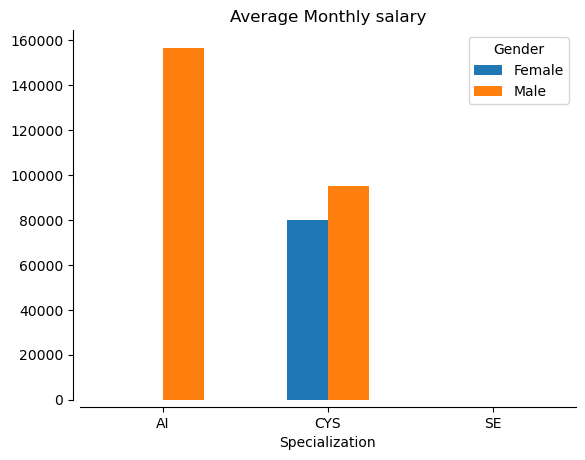

In [32]:
# Grouped bar chart
plt.figure(figsize=(10, 5))

gropud_data = df.groupby(['Specialization', 'Gender'])['Monthly_Salary_PKR'].mean().unstack('Gender')
gropud_data.plot(kind='bar')
plt.title("Average Monthly salary")

sns.despine(offset=5)
plt.show()

**📝 Observation:**

*SE Graduates don't have job/salary. while females have less salary then males*

## Part (b) — Side-by-Side Pie Charts: Job Status & Sector Breakdown

Create a single figure with two pie charts side by side:
- **Left:** `Job_Status` breakdown for all graduates
- **Right:** `Job_Sector` breakdown for employed students only

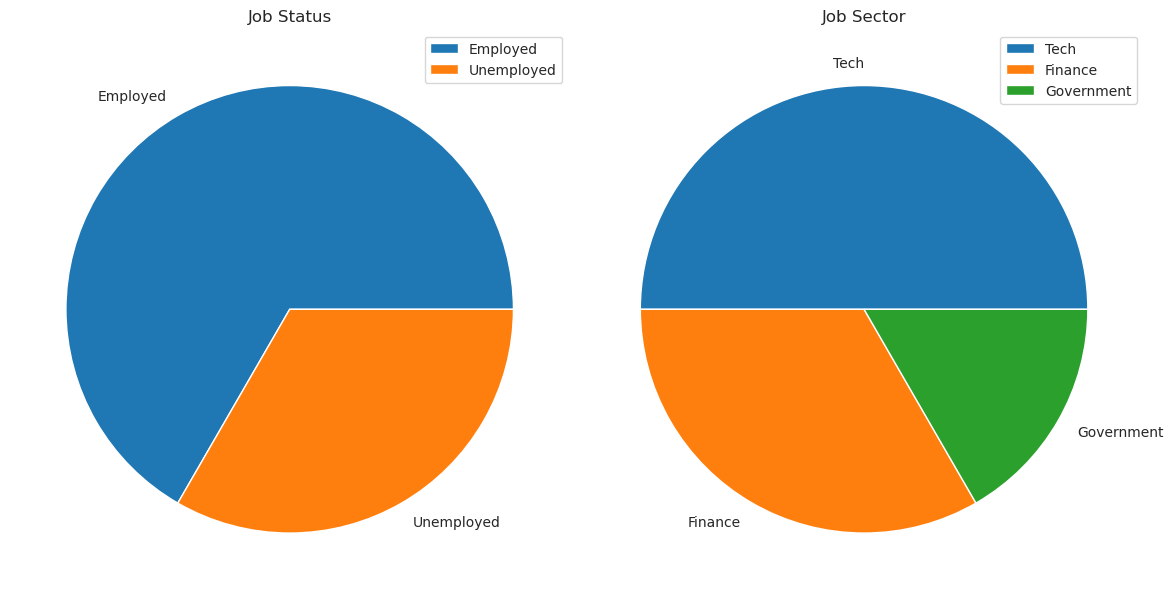

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left chart — Job_Status (all graduates)
jst_counts = df['Job_Status'].value_counts()
axes[0].pie(jst_counts, labels=jst_counts.index.tolist())
axes[0].set_title('Job Status')
axes[0].legend()

# Right chart — Job_Sector (employed only)
js_counts = df[df['Job_Status'] == 'Employed']['Job_Sector'].value_counts()
axes[1].pie(js_counts, labels=js_counts.index.tolist())
axes[1].set_title('Job Sector')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part (c) — Box Plot: CGPA Distribution Across Skill Levels

Create a box plot of `CGPA` grouped by `Skill_Level`. The x-axis must follow the logical order: **Beginner → Intermediate → Advanced**.

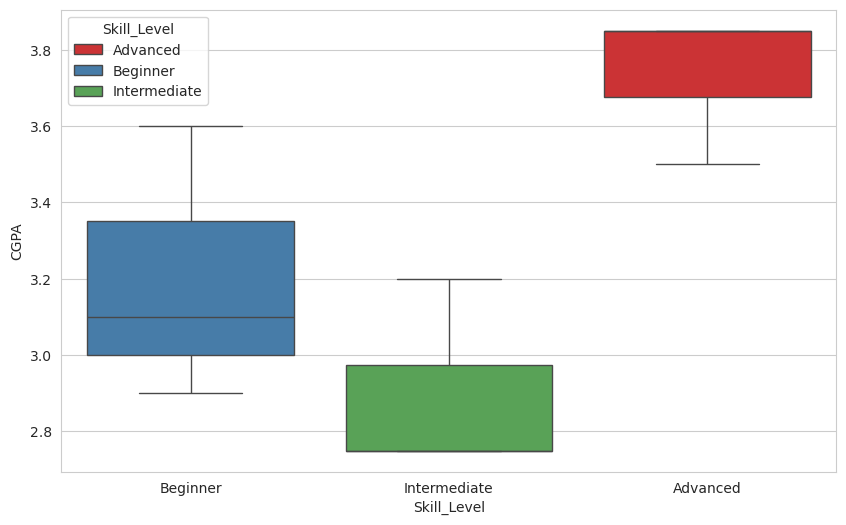

In [44]:
# Box plot — enforce logical order on x-axis
order = ['Beginner', 'Intermediate', 'Advanced']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.boxplot(x='Skill_Level', y='CGPA', hue='Skill_Level', data=df, order=order, palette="Set1", legend=True) # pallete is for colors
# plt.legend()
plt.show()

**📝 Observation:**

*Beginers have all kind of CGPAs, but skewed towards low cpgas. but Intermediate has lower CGPAs while Advanced have very high CGPAs*

## Part (d) — Correlation Heatmap & Feature Dropping

Plot an annotated correlation heatmap of all numerical features. Then identify the top 2 features most correlated with `Monthly_Salary_PKR` and drop the least correlated one.

In [52]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df.corr()

,CGPA,Graduation_Year,Monthly_Salary_PKR,Experience_Months,CGPA_scaled,Monthly_Salary_PKR_scaled,Experience_Months_scaled,Job_Status_encoded,Skill_Level_encoded
CGPA,1.000000,2.757905e-01,0.475294,0.477027,1.000000,0.475294,0.477027,0.132715,5.254145e-01
Graduation_Year,0.275790,1.000000e+00,0.243216,0.076139,0.275790,0.243216,0.076139,-0.158114,1.112812e-14
Monthly_Salary_PKR,0.475294,2.432164e-01,1.000000,0.982993,0.475294,1.000000,0.982993,0.879670,9.712736e-01
Experience_Months,0.477027,7.613870e-02,0.982993,1.000000,0.477027,0.982993,1.000000,0.872797,9.383149e-01
CGPA_scaled,1.000000,2.757905e-01,0.475294,0.477027,1.000000,0.475294,0.477027,0.132715,5.254145e-01
Monthly_Salary_PKR_scaled,0.475294,2.432164e-01,1.000000,0.982993,0.475294,1.000000,0.982993,0.879670,9.712736e-01
Experience_Months_scaled,0.477027,7.613870e-02,0.982993,1.000000,0.477027,0.982993,1.000000,0.872797,9.383149e-01
Job_Status_encoded,0.132715,-1.581139e-01,0.879670,0.872797,0.132715,0.879670,0.872797,1.000000,8.660254e-01
Skill_Level_encoded,0.525414,1.112812e-14,0.971274,0.938315,0.525414,0.971274,0.938315,0.866025,1.000000e+00


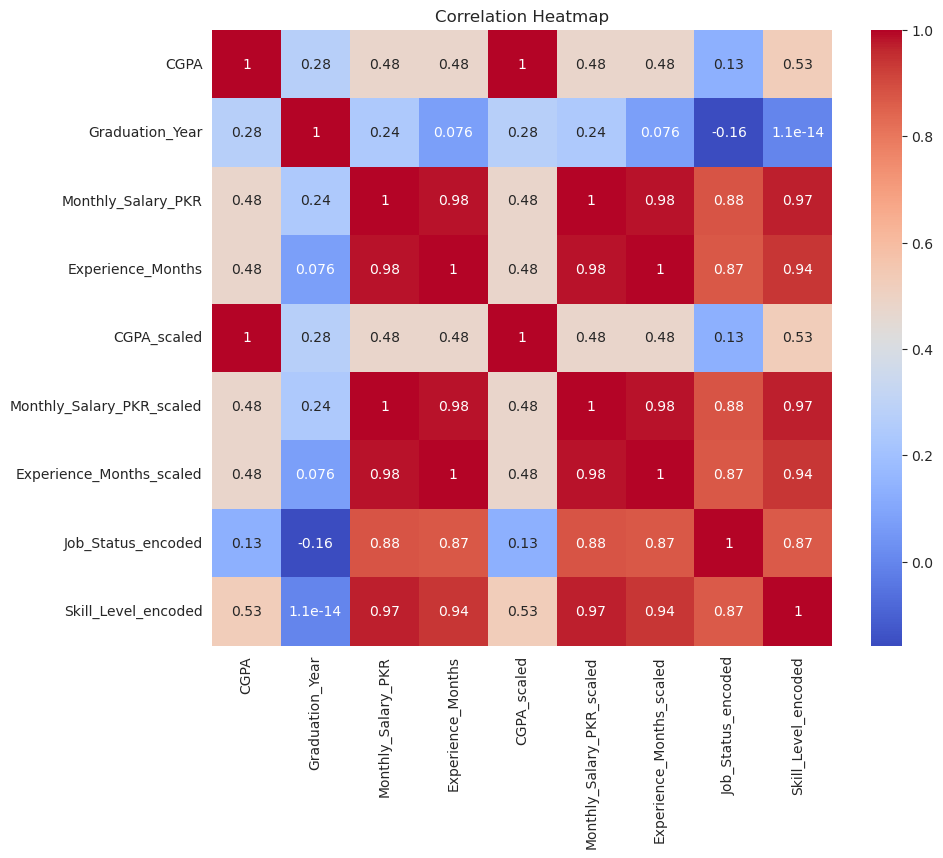

In [55]:
# Correlation heatmap (annotated)
numerical_df = df.select_dtypes(include=['float64', 'int64'])
cm = numerical_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [56]:
# Print correlation values with Monthly_Salary_PKR and identify top 2 and least correlated
cm['Monthly_Salary_PKR']

CGPA                         0.475294
Graduation_Year              0.243216
Monthly_Salary_PKR           1.000000
Experience_Months            0.982993
CGPA_scaled                  0.475294
Monthly_Salary_PKR_scaled    1.000000
Experience_Months_scaled     0.982993
Job_Status_encoded           0.879670
Skill_Level_encoded          0.971274
Name: Monthly_Salary_PKR, dtype: float64

In [62]:
# Drop the least correlated feature from the dataset
df = df.drop('Graduation_Year', axis=1)
# df.drop(columns=['Graduation_Year '], inplace=True, axis=1)

**📝 Findings & Justification:**

| | Feature | Correlation with Monthly_Salary_PKR |
|---|---|---|
| Most correlated #1 | *Experience_Months_scaled* | *0.982993* |
| Most correlated #2 | *Skill_Level_encoded* | *0.971274* |
| Least correlated (dropped) | *Graduation_Year* | *0.243216* |

**Why I dropped this feature:** *Monthly salary is least defined by the year of greaduation*

## Part (e) — Critical Thinking: Demonstrating Data Leakage

Show the wrong approach (scale before split) vs the correct approach (split first, scale train only) using the `CGPA` column. Print both results side by side.

In [7]:
df_cgpa = df[['CGPA']]
df_cgpa

,CGPA
0,3.85
1,2.90
2,NaN
3,3.50
4,3.10
5,2.75
6,NaN
7,3.60
8,3.20
9,3.85


In [14]:
# ❌ WRONG approach — scale entire dataset BEFORE train/test split
scaller = MinMaxScaler()
df_cgpa['gpa_wrong_scale'] = scaller.fit_transform(df_cgpa[['CGPA']])

train_w, test_w = train_test_split(df_cgpa, test_size=0.25, random_state=42)

In [15]:
# ✅ CORRECT approach — split first, then fit scaler on train only, transform test separately
train_c, test_c = train_test_split(df_cgpa, test_size=0.25, random_state=42)

train_c['gpa_correct_scale'] = scaller.fit_transform(train_c[['CGPA']])
test_c['gpa_correct_scale'] = scaller.transform(test_c[['CGPA']])

In [16]:
# Print scaled CGPA values from both approaches side by side
print("Wrong approach:")
print("train:")
print(train_w[['CGPA', 'gpa_wrong_scale']])
print("test:")
print(test_w[['CGPA', 'gpa_wrong_scale']])

print("Correct approach:")
print("train")
print(train_c[['CGPA', 'gpa_correct_scale']])
print("test")
print(test_c[['CGPA', 'gpa_correct_scale']])

Wrong approach:
train:
   CGPA  gpa_wrong_scale
0  3.85         1.000000
7  3.60         0.772727
2   NaN              NaN
9  3.85         1.000000
4  3.10         0.318182
3  3.50         0.681818
6   NaN              NaN
test:
   CGPA  gpa_wrong_scale
8  3.20         0.409091
1  2.90         0.136364
5  2.75         0.000000
Correct approach:
train
   CGPA  gpa_correct_scale
0  3.85           1.000000
7  3.60           0.666667
2   NaN                NaN
9  3.85           1.000000
4  3.10           0.000000
3  3.50           0.533333
6   NaN                NaN
test
   CGPA  gpa_correct_scale
8  3.20           0.133333
1  2.90          -0.266667
5  2.75          -0.466667


**📝 Explanation — What went wrong in the wrong approach and why it matters:**

### Data Leakage Explanation

In the wrong approach, MinMaxScaler was fitted on the entire dataset before splitting. This means the scaler computed the global minimum and maximum CGPA values using both training and test data.

#### What leaked?
The **minimum and maximum values of the CGPA column from the test set** leaked into the training process.

#### Why is this a problem?
- The model indirectly gains information about the test distribution.
- Scaling becomes artificially "perfect" because it uses future (test) data.
- This leads to overly optimistic evaluation metrics.
- In real-world deployment, test data is unknown — so this setup is unrealistic.

#### Correct behavior:
- Fit preprocessing steps ONLY on training data.
- Apply the learned transformation to test data using `.transform()`.

This ensures that the model evaluation reflects true generalization performance.

---
## Submission

1. Make sure all cells are executed and outputs are visible.
2. Download **AI_Lab8.ipynb** from Jupyter.
3. Rename your Jupyter notebook to your roll number and download as **.ipynb** extension.